# 01 — Exploratory Data Analysis

This notebook explores the raw daily OHLCV dataset before any factors are created. Each text section introduces the analysis that belongs in the code cell beneath it.

## 1. Load the data

Begin with a small, fixed group of symbols and a clear historical period. Load the data with `YahooFinanceDataLoader`, then inspect the first rows, dimensions, and data types. The analysis table should have one observation for each trading date and stock symbol.

In [58]:
from curl_cffi import requests
from factor_model.data import YahooFinanceDataLoader

# Bypass zscaler
insecure_session = requests.Session(
    impersonate="chrome",
    verify=False)

yd = YahooFinanceDataLoader(session=insecure_session)

symbols = [
    "AAPL",  # technology
    "MSFT",
    "JPM",   # banking
    "JNJ",   # healthcare
    "XOM",   # energy
    "WMT",   # consumer defensive
    "HD",    # consumer cyclical
    "CAT",   # industrials
    "NEE",   # utilities
    "AMGN",  # healthcare
]

start_date = "2018-01-01"
end_date = "2025-01-01"  # Yahoo's end date is exclusive

df = yd.load(symbols, start_date, end_date)

# 2. Check data quality
- The pair `(date, symbol)` is the natural key for this dataset, so it must be unique. 
- Check the ordering and missing values in each column before making any transformations. 
- Inspect and describe problems before deciding how to handle them.


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17610 entries, 0 to 17609
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   date            17610 non-null  datetime64[s]
 1   symbol          17610 non-null  str          
 2   open            17610 non-null  float64      
 3   high            17610 non-null  float64      
 4   low             17610 non-null  float64      
 5   close           17610 non-null  float64      
 6   adjusted_close  17610 non-null  float64      
 7   volume          17610 non-null  int64        
dtypes: datetime64[s](1), float64(5), int64(1), str(1)
memory usage: 1.1 MB


In [20]:
df.head(25)

Price,date,symbol,open,high,low,close,adjusted_close,volume
0,2018-01-02,AAPL,42.540001,43.075001,42.314999,43.064999,40.232376,102223600
1,2018-01-02,AMGN,175.350006,177.820007,174.419998,177.000000,135.948074,2301100
2,2018-01-02,CAT,158.300003,159.389999,156.029999,157.039993,131.050797,5108400
3,2018-01-02,HD,190.210007,190.720001,188.009995,188.029999,151.531250,4684700
4,2018-01-02,JNJ,139.660004,139.949997,138.720001,139.229996,109.590324,6842100
5,2018-01-02,JPM,107.629997,108.019997,106.809998,107.949997,85.516029,13578800
6,2018-01-02,MSFT,86.129997,86.309998,85.500000,85.949997,78.552032,22483800
7,2018-01-02,NEE,39.107498,39.167500,38.605000,38.772499,31.100231,4766400
8,2018-01-02,WMT,33.099998,33.263332,32.840000,32.863335,28.731449,30451500
9,2018-01-02,XOM,83.820000,85.199997,83.660004,85.029999,57.811150,11469300


In [ ]:
dups = df.duplicated(subset=["date", "symbol"])
dups.sum()
assert not dups.any(), "Duplicate (date, symbol) found"
# df.loc[duplicate_pairs, ["date", "symbol"]]

## 3. Inspect coverage

Summarize the number of observations, first date, and last date for each symbol. Compare daily coverage across the universe. A missing date for one stock can later look like an extreme return when data is aligned incorrectly, so coverage must be understood before calculating returns.

In [39]:
df.groupby("symbol").agg({"date": ["min", "max"]})


Price        date           
              min        max
symbol                      
AAPL   2018-01-02 2024-12-31
AMGN   2018-01-02 2024-12-31
CAT    2018-01-02 2024-12-31
HD     2018-01-02 2024-12-31
JNJ    2018-01-02 2024-12-31
JPM    2018-01-02 2024-12-31
MSFT   2018-01-02 2024-12-31
NEE    2018-01-02 2024-12-31
WMT    2018-01-02 2024-12-31
XOM    2018-01-02 2024-12-31

In [40]:
coverage_by_symbol = df.groupby("symbol").agg(
    observations=("date", "size"),
    first_date=("date", "min"),
    last_date=("date", "max")
)

coverage_by_symbol

,observations,first_date,last_date
symbol,,,
AAPL,1761,2018-01-02,2024-12-31
AMGN,1761,2018-01-02,2024-12-31
CAT,1761,2018-01-02,2024-12-31
HD,1761,2018-01-02,2024-12-31
JNJ,1761,2018-01-02,2024-12-31
JPM,1761,2018-01-02,2024-12-31
MSFT,1761,2018-01-02,2024-12-31
NEE,1761,2018-01-02,2024-12-31
WMT,1761,2018-01-02,2024-12-31


## 4. Validate market fields

1) Prices should be positive and volume should not be negative.
2) The daily low must not exceed the open, close, or high, and the high must not be below the open, close, or low.
3) Inspect zero-volume observations separately: they may be valid, or they may signal a data limitation that needs a rule later in the pipeline.

In [ ]:
display(df.info())
print("Check positivity of prices.")
assert df[df["open"] <= 0].size == 0, "Negative stock price in ('open')"
assert df[df["high"] <= 0].size == 0, "Negative stock price in ('high')"
assert df[df["low"] <= 0].size == 0, "Negative stock price in ('low')"
assert df[df["close"] <= 0].size == 0, "Negative stock price in ('close')"

print("Check non-negatity of volume.")
assert df[df["volume"] < 0].size == 0

print("Check daily low validity.")
invalid_low = df[
  (df["low"] > df["open"]) |
  (df["low"] > df["close"]) |
  (df["low"] > df["high"])
]
assert invalid_low.empty, "Found rows where low is invalid"

print("Check daily high validity.")
invalid_high = df[
  (df["high"] < df["open"]) |
  (df["high"] < df["close"]) |
  (df["high"] < df["low"])
]
assert invalid_high.empty, "Found rows where low is invalid"


<class 'pandas.DataFrame'>
RangeIndex: 17610 entries, 0 to 17609
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   date            17610 non-null  datetime64[s]
 1   symbol          17610 non-null  str          
 2   open            17610 non-null  float64      
 3   high            17610 non-null  float64      
 4   low             17610 non-null  float64      
 5   close           17610 non-null  float64      
 6   adjusted_close  17610 non-null  float64      
 7   volume          17610 non-null  int64        
dtypes: datetime64[s](1), float64(5), int64(1), str(1)
memory usage: 1.1 MB


None

Check positivity of prices.
Check non-negatity of volume.
Check daily low validity.
Check daily high validity.


In [57]:
df[df["volume"] == 0]

Price,date,symbol,open,high,low,close,adjusted_close,volume


## 5. Explore prices and volume

Use `adjusted_close` for return-based analysis because it accounts for corporate actions. Plot a readable subset of price series, then normalize every series to a common starting value to compare performance instead of dollar price levels. Summarize volume as well, since very low trading activity can make a stock unsuitable for a trading strategy.

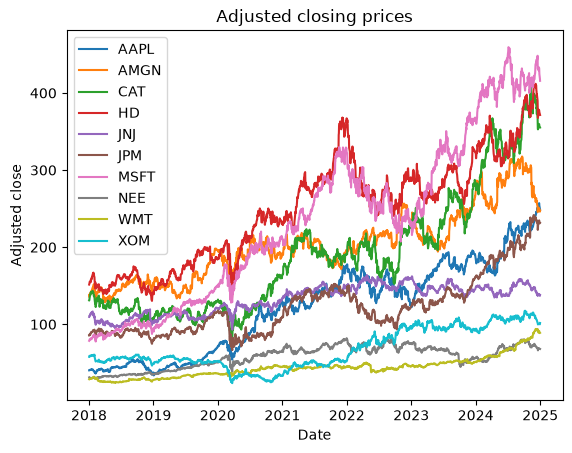

In [61]:
import matplotlib.pyplot as plt

for symbol, symbol_data in df.groupby("symbol"):
  plt.plot(
    symbol_data["date"],
    symbol_data["adjusted_close"],
    label=symbol,
  )

plt.title("Adjusted closing prices")
plt.xlabel("Date")
plt.ylabel("Adjusted close")
plt.legend()
plt.show()

In [71]:
df["normalized_price"] = (
    df["adjusted_close"] / df.groupby("symbol")["adjusted_close"].transform("first") * 100
) 
df.head(25)

Price,date,symbol,open,high,low,close,adjusted_close,volume,normalized_price
0,2018-01-02,AAPL,42.540001,43.075001,42.314999,43.064999,40.232376,102223600,100.000000
1,2018-01-02,AMGN,175.350006,177.820007,174.419998,177.000000,135.948074,2301100,100.000000
2,2018-01-02,CAT,158.300003,159.389999,156.029999,157.039993,131.050797,5108400,100.000000
3,2018-01-02,HD,190.210007,190.720001,188.009995,188.029999,151.531250,4684700,100.000000
4,2018-01-02,JNJ,139.660004,139.949997,138.720001,139.229996,109.590324,6842100,100.000000
5,2018-01-02,JPM,107.629997,108.019997,106.809998,107.949997,85.516029,13578800,100.000000
6,2018-01-02,MSFT,86.129997,86.309998,85.500000,85.949997,78.552032,22483800,100.000000
7,2018-01-02,NEE,39.107498,39.167500,38.605000,38.772499,31.100231,4766400,100.000000
8,2018-01-02,WMT,33.099998,33.263332,32.840000,32.863335,28.731449,30451500,100.000000
9,2018-01-02,XOM,83.820000,85.199997,83.660004,85.029999,57.811150,11469300,100.000000


In [72]:
df.groupby("symbol")["volume"].agg(["min", "median", "mean", "max"])

,min,median,mean,max
symbol,,,,
AAPL,23234700,86712000.0,1.001417e+08,426510000
AMGN,612800,2491900.0,2.835031e+06,19115500
CAT,585700,3160700.0,3.670498e+06,24122300
HD,1093900,3670500.0,4.147097e+06,19752800
JNJ,2114900,6717800.0,7.934652e+06,151319500
JPM,3220500,11583200.0,1.322258e+07,54418800
MSFT,7164500,25460100.0,2.847806e+07,111242100
NEE,1387500,7905200.0,8.935780e+06,54022800
WMT,6287500,19270800.0,2.264874e+07,156265500


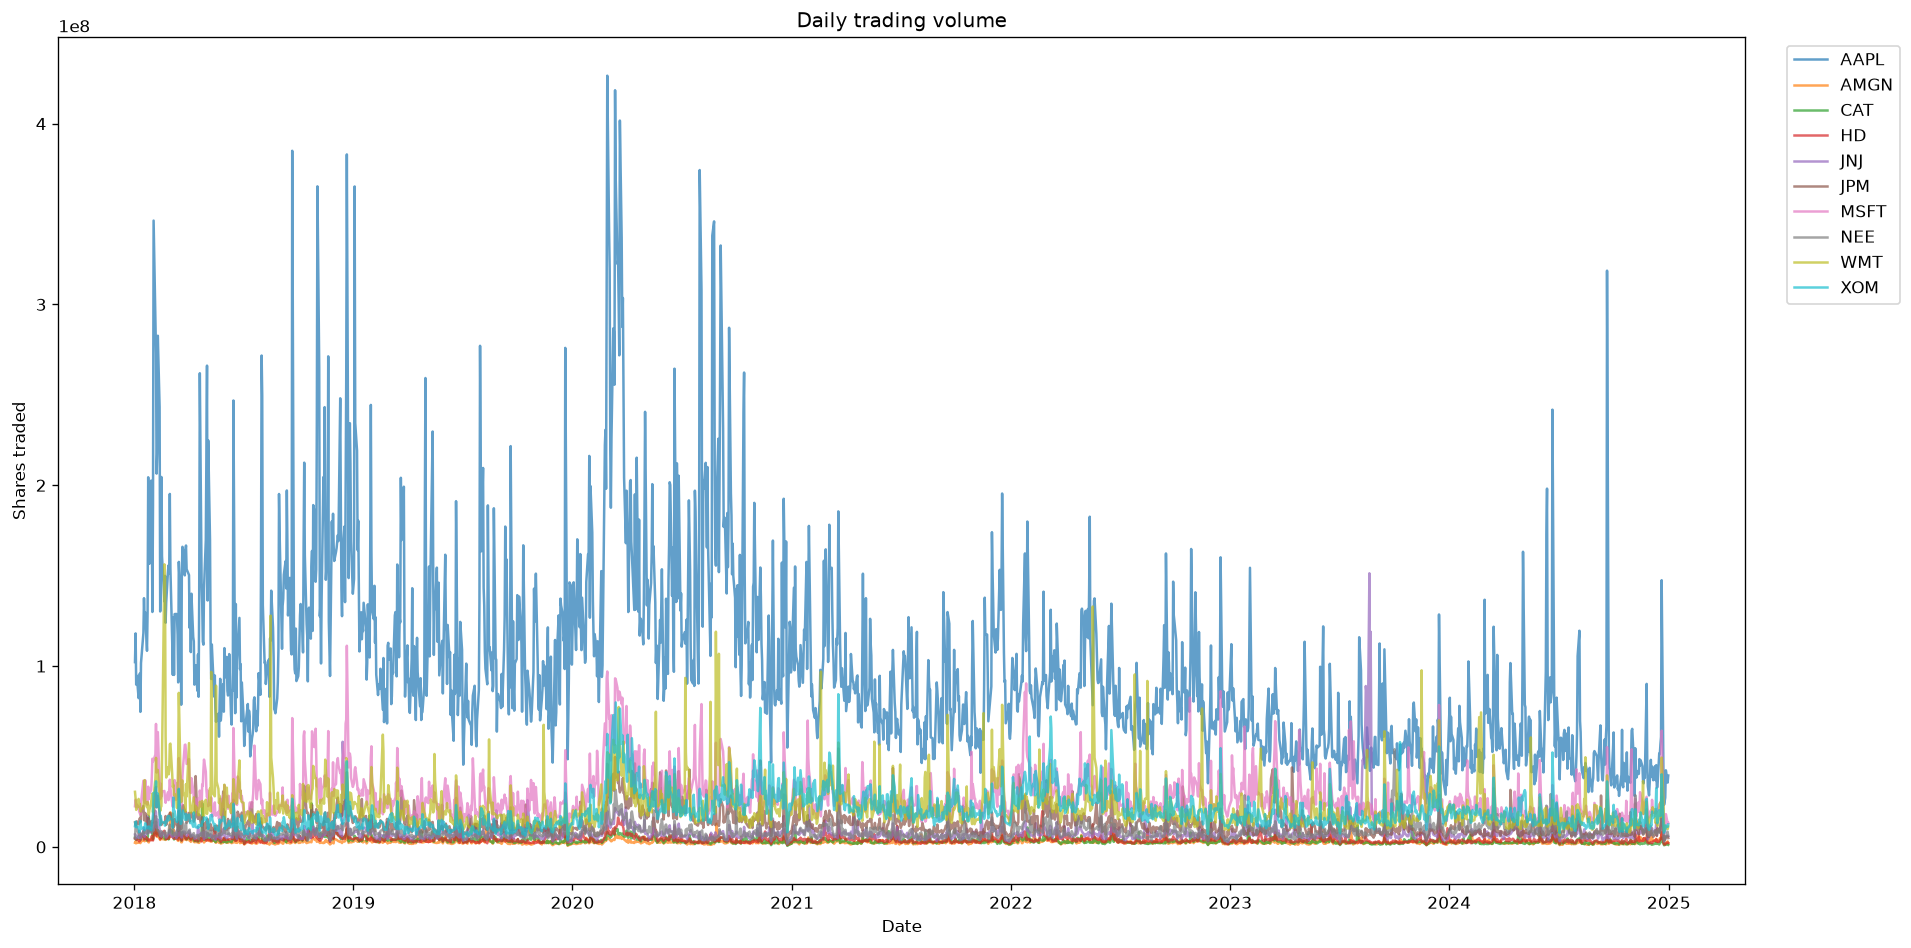

In [82]:
plt.figure(figsize=(16, 8), dpi=120)

for symbol, symbol_data in df.groupby("symbol"):
  plt.plot(
    symbol_data["date"],
    symbol_data["volume"],
    label=symbol,
    alpha=0.7,
  )

plt.title("Daily trading volume")
plt.xlabel("Date")
plt.ylabel("Shares traded")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [76]:
df["dollar_volume"] = df["close"] * df["volume"]
df.head()

Price,date,symbol,open,high,low,close,adjusted_close,volume,normalized_price,dollar_volume
0,2018-01-02,AAPL,42.540001,43.075001,42.314999,43.064999,40.232376,102223600,100.0,4.402259e+09
1,2018-01-02,AMGN,175.350006,177.820007,174.419998,177.000000,135.948074,2301100,100.0,4.072947e+08
2,2018-01-02,CAT,158.300003,159.389999,156.029999,157.039993,131.050797,5108400,100.0,8.022231e+08
3,2018-01-02,HD,190.210007,190.720001,188.009995,188.029999,151.531250,4684700,100.0,8.808641e+08
4,2018-01-02,JNJ,139.660004,139.949997,138.720001,139.229996,109.590324,6842100,100.0,9.526256e+08


## 6. Explore daily returns

1) Calculate daily returns separately within each symbol, using adjusted close. 
2) Summarize and visualize the resulting distributions, then inspect the largest positive and negative observations. 
3) Verify at least one result manually from two consecutive prices; this makes the calculation concrete before later rolling features depend on it.

In [96]:
df = df.sort_values(["symbol", "date"])

df["daily_return"] = (
  df.groupby("symbol")["adjusted_close"]
    .pct_change(fill_method=None)
)
df["five_day_return"] = (
  df.groupby("symbol")["adjusted_close"]
    .pct_change(fill_method=None, periods=5)
)
df["twenty_day_return"] = (
  df.groupby("symbol")["adjusted_close"]
    .pct_change(fill_method=None, periods=20)
)
df.groupby("symbol").agg(
    mean_return=("daily_return", "mean"),
  volatility=("daily_return", "std"),
    max_return=("daily_return", "max"),
    min_return=("daily_return", "min")
)


,mean_return,volatility,max_return,min_return
symbol,,,,
AAPL,0.001220,0.019242,0.119808,-0.128647
AMGN,0.000465,0.015847,0.118179,-0.082608
CAT,0.000768,0.020014,0.103320,-0.142822
HD,0.000653,0.016848,0.137508,-0.197938
JNJ,0.000207,0.012325,0.079977,-0.100379
JPM,0.000739,0.018640,0.180125,-0.149649
MSFT,0.001113,0.018197,0.142169,-0.147390
NEE,0.000590,0.017024,0.136904,-0.134171
WMT,0.000736,0.013734,0.117085,-0.113757


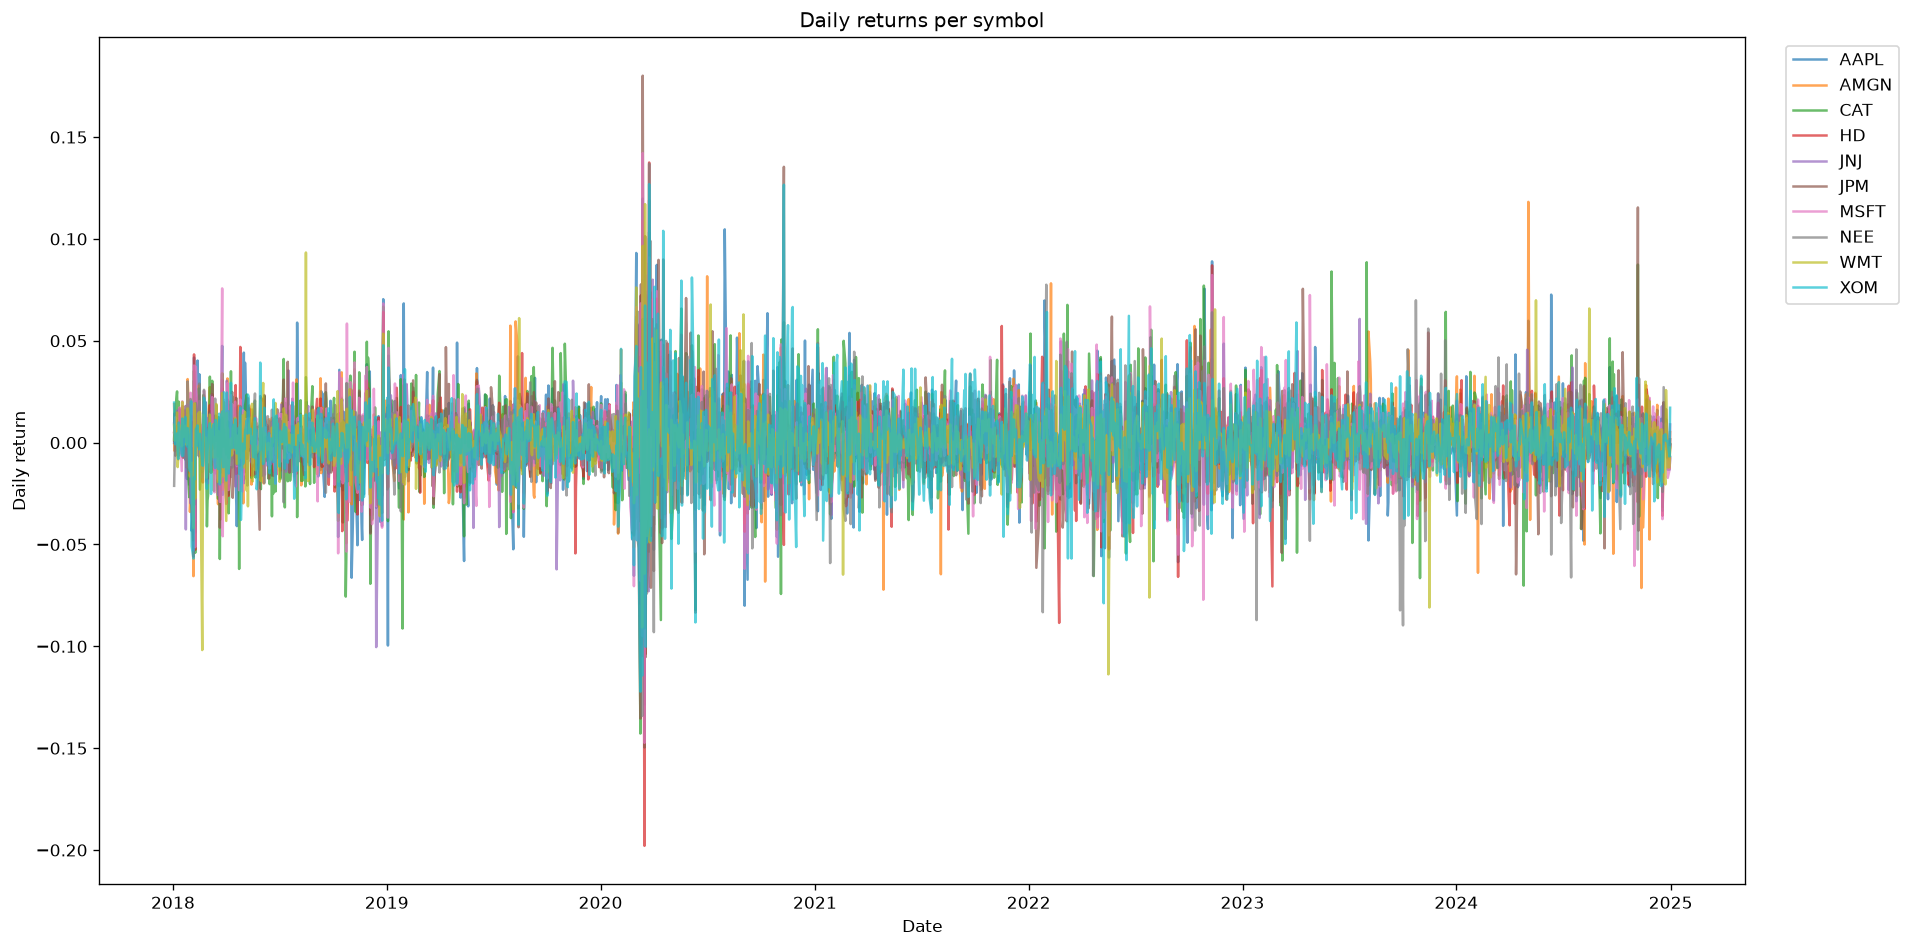

In [97]:
plt.figure(figsize=(16, 8), dpi=120)

for symbol, symbol_data in df.groupby("symbol"):
  plt.plot(
    symbol_data["date"],
    symbol_data["daily_return"],
    label=symbol,
    alpha=0.7,
  )

plt.title("Daily returns per symbol")
plt.xlabel("Date")
plt.ylabel("Daily return")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

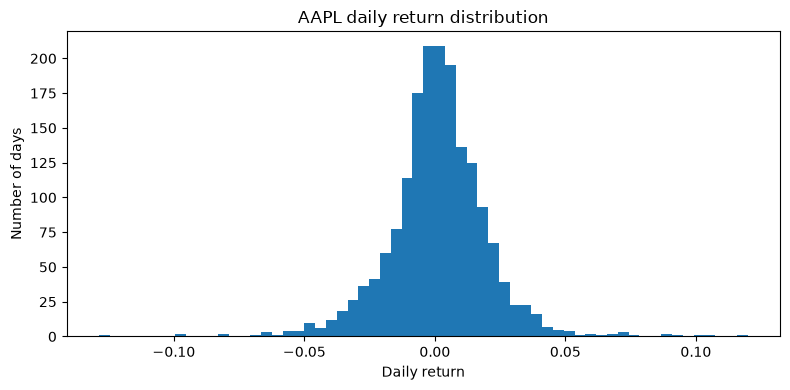

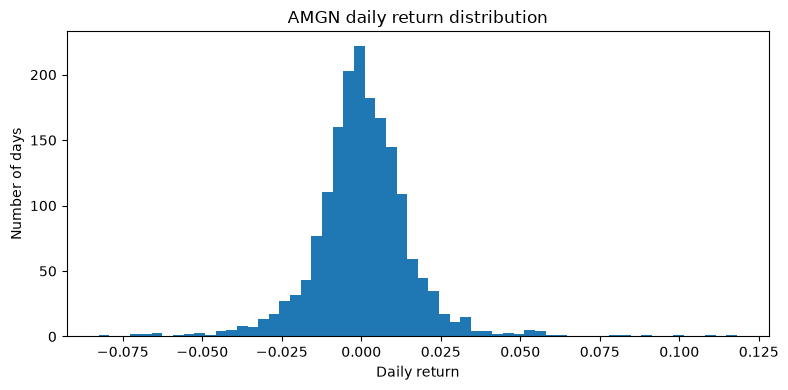

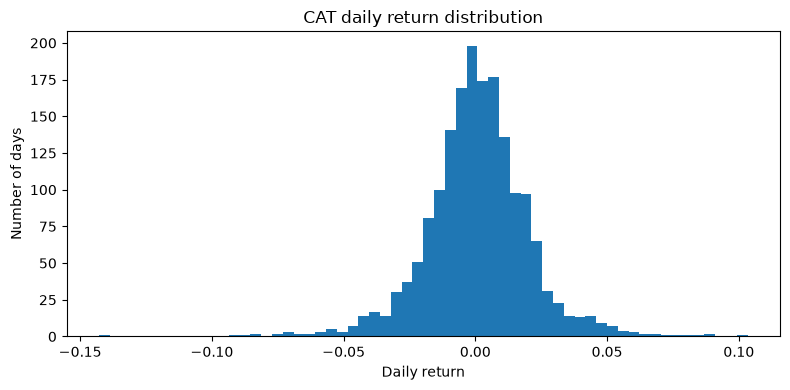

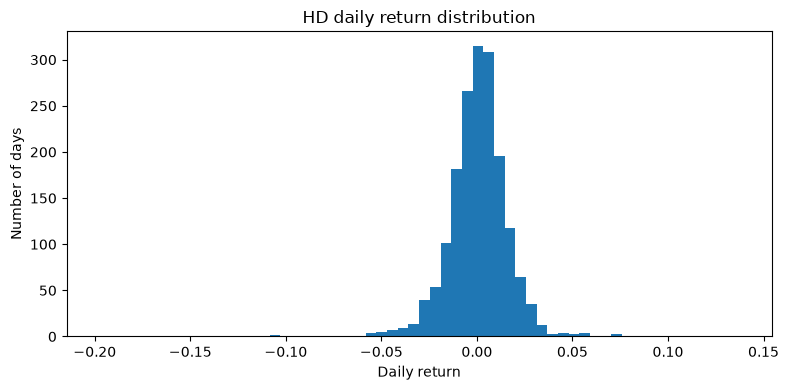

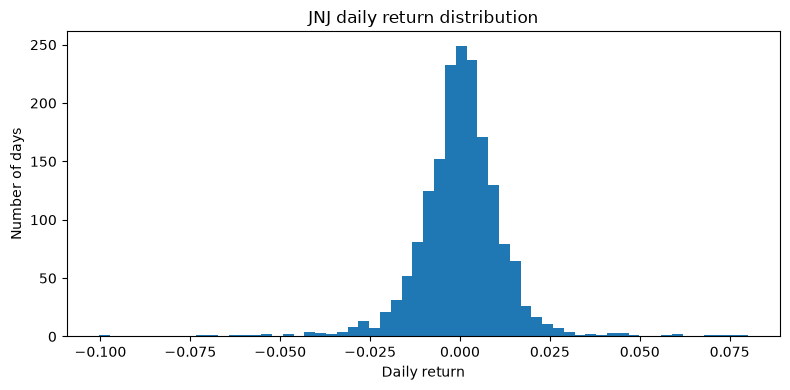

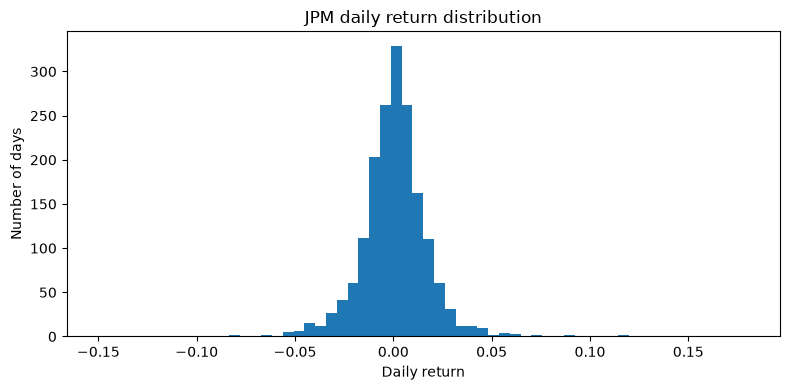

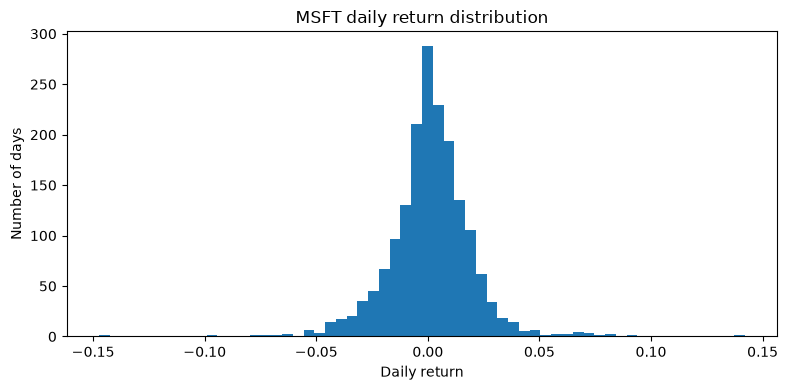

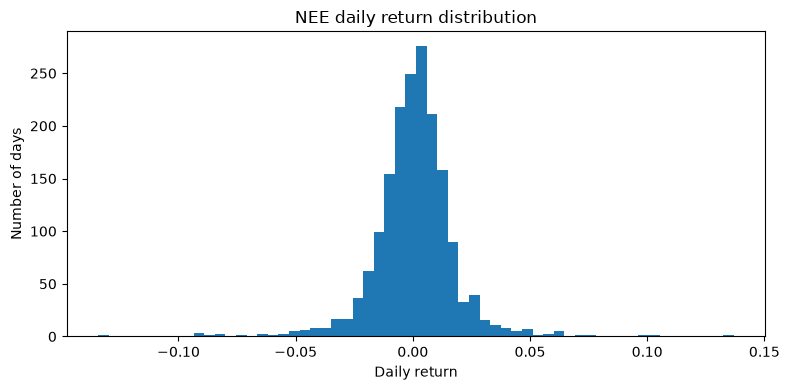

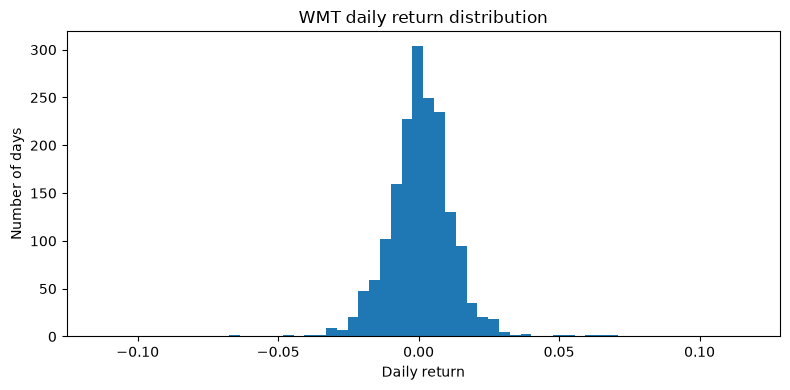

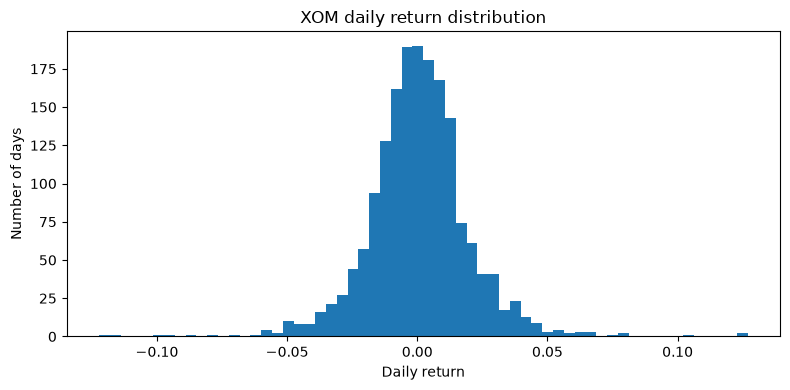

In [98]:
for symbol, symbol_data in df.groupby("symbol"):
  plt.figure(figsize=(8, 4))

  plt.hist(symbol_data["daily_return"].dropna(), bins=60)

  plt.title(f"{symbol} daily return distribution")
  plt.xlabel("Daily return")
  plt.ylabel("Number of days")
  plt.tight_layout()
  plt.show()

## 7. Explore the cross-section

The project ranks stocks against their peers rather than forecasting one stock in isolation. 
1) On selected dates, compare symbols using a simple recent return and inspect the distribution across stocks.
2) Also count the available symbols each day, because a stable and sufficiently broad universe is necessary for meaningful ranks.

In [100]:
df["daily_rank"] = df.groupby("date").daily_return.rank(ascending=False)
df["five_day_rank"] = df.groupby("date").five_day_return.rank(ascending=False)
df["twenty_day_rank"] = df.groupby("date").twenty_day_return.rank(ascending=False)
df.head()

Price,date,symbol,open,high,low,close,adjusted_close,volume,normalized_price,dollar_volume,daily_return,daily_rank,five_day_return,twenty_day_return,five_day_rank,twenty_day_rank
0,2018-01-02,AAPL,42.540001,43.075001,42.314999,43.064999,40.232376,102223600,100.000000,4.402259e+09,NaN,NaN,NaN,NaN,NaN,NaN
10,2018-01-03,AAPL,43.132500,43.637501,42.990002,43.057499,40.225368,118071600,99.982582,5.083868e+09,-0.000174,9.0,NaN,NaN,NaN,NaN
20,2018-01-04,AAPL,43.134998,43.367500,43.020000,43.257500,40.412212,89738400,100.446994,3.881859e+09,0.004645,5.0,NaN,NaN,NaN,NaN
30,2018-01-05,AAPL,43.360001,43.842499,43.262501,43.750000,40.872322,94640000,101.590624,4.140500e+09,0.011385,3.0,NaN,NaN,NaN,NaN
40,2018-01-08,AAPL,43.587502,43.902500,43.482498,43.587502,40.720516,82271200,101.213302,3.585996e+09,-0.003714,10.0,NaN,NaN,NaN,NaN


## Next step

After the EDA, preserve the important findings in your notebook or project notes. They should guide the eligibility rules and feature definitions. Feature engineering can then build rolling momentum, reversal, volatility, and volume measures using only information known on each trading date.

## EDA findings

The downloaded dataset contains **17,610 observations across 10 stocks**. Each stock has 1,761 observations, with the same first and last dates: January 2, 2018 and December 31, 2024. Matching counts and endpoints do not yet confirm that every stock is present on every date; daily coverage still needs a direct check.

### Data quality

The eight raw columns contain no missing values, and the `(date, symbol)` pairs are unique. The checks for positive OHLC prices, non-negative volume, and consistent daily high/low relationships passed. No zero-volume observations were found.

### Trading activity and daily returns

AAPL has the highest median share volume, approximately 86.7 million shares per day. AMGN has the lowest at approximately 2.49 million, followed by CAT at 3.16 million. These are share-volume comparisons; dollar-volume summaries are still needed to compare approximate trading value.

CAT has the highest daily return standard deviation in this sample, approximately 2.00%, while JNJ has the lowest at 1.23%. The largest observed positive daily return is JPM's +18.01%, and the largest negative daily return is HD's -19.79%. The dates and surrounding observations behind these extremes still need inspection.

### Derived measurements

The notebook calculates normalized prices, approximate dollar volume (`close * volume`), past 1-, 5-, and 20-day returns, and cross-sectional ranks for those return horizons. Return calculations are grouped by symbol and sorted chronologically; rankings are calculated separately within each date, with the highest return assigned rank 1.

Missing return and rank values at the beginning of each stock's history are expected: a return requires 1, 5, or 20 preceding observations. Normalized prices support visualization, while past returns and their ranks are potential model features. Their predictive usefulness has not yet been tested.

### Remaining analysis

- Confirm the number of available symbols on every observed date.
- Plot normalized prices to compare cumulative performance.
- Summarize dollar volume by symbol.
- Inspect returns and ranks on selected dates, including the best-minus-worst return spread.
- Inspect the dates behind extreme returns and verify one return manually.

### Implications for feature engineering

The existing checks support using this dataset for the next research stage once the remaining coverage and extreme-return checks are resolved. Define an explicit rule for insufficient lookback history, and calculate features using only information available by their date. The selected universe contains surviving companies, so historical results will have survivorship bias and should not be generalized to all stocks.